<a href="https://colab.research.google.com/github/nameershah/ml-salary-prediction/blob/main/Simple_Linear_Regression_Salary_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
# ── Cell 1: Install libraries (only needed if not on Colab) ──────────────────
!pip install pandas numpy matplotlib scikit-learn seaborn

In [49]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [50]:
# ── Cell 3: Load Dataset ─────────────────────────────────────────────────────
df = pd.read_csv('Salary_dataset.csv')

In [51]:
# ── Cell 4: Exploratory Data Analysis (EDA) ──────────────────────────────────
from IPython.display import display

# Shape
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}\n")

# Head
print("── First 5 Rows ──")
display(df.head())

# Tail
print("── Last 5 Rows ──")
display(df.tail())

# Data Types
print("── Column Info ──")
info_df = pd.DataFrame({
    'Column'   : df.columns,
    'Dtype'    : df.dtypes.values,
    'Non-Null' : df.notnull().sum().values,
    'Nulls'    : df.isnull().sum().values
})
display(info_df)

# Descriptive Stats
print("── Descriptive Statistics ──")
display(df.describe().round(2))

# Missing Values
print("── Missing Values ──")
missing_df = pd.DataFrame({
    'Column'       : df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %'    : (df.isnull().sum().values / len(df) * 100).round(2)
})
display(missing_df)

Rows: 30  |  Columns: 3

── First 5 Rows ──


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


── Last 5 Rows ──


,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


── Column Info ──


,Column,Dtype,Non-Null,Nulls
0,Unnamed: 0,int64,30,0
1,YearsExperience,float64,30,0
2,Salary,float64,30,0


── Descriptive Statistics ──


,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


── Missing Values ──


,Column,Missing Count,Missing %
0,Unnamed: 0,0,0.0
1,YearsExperience,0,0.0
2,Salary,0,0.0


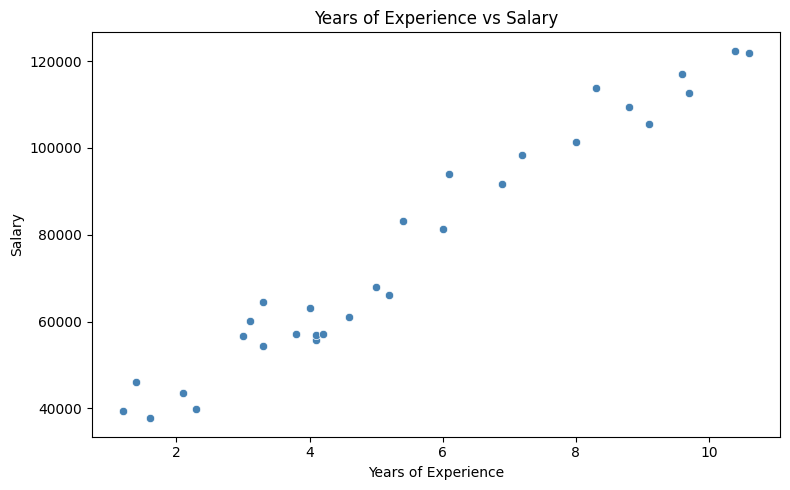

In [52]:
# ── Cell 5: Visualize the raw data ───────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='YearsExperience', y='Salary', color='steelblue')
plt.title('Years of Experience vs Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

                 Unnamed: 0  YearsExperience    Salary
Unnamed: 0         1.000000         0.986460  0.960826
YearsExperience    0.986460         1.000000  0.978242
Salary             0.960826         0.978242  1.000000


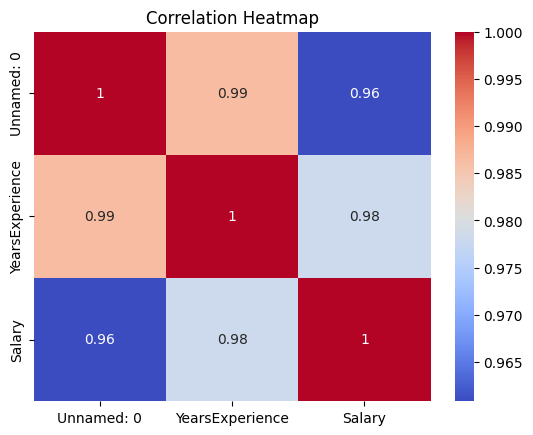

In [53]:
# ── Cell 6: Correlation ───────────────────────────────────────────────────────
print(df.corr())
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [54]:
# ── Cell 7: Prepare features and target ──────────────────────────────────────
X = df[['YearsExperience']]
y = df['Salary']

In [55]:
# ── Cell 8: Fit on FULL dataset (no split) ───────────────────────────────────
model = LinearRegression()
model.fit(X, y)   # X and y — full data, no split

print(f"Intercept  : {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Equation   : Salary = {model.coef_[0]:.2f} * YearsExp + {model.intercept_:.2f}")

Intercept  : 24848.20
Coefficient: 9449.96
Equation   : Salary = 9449.96 * YearsExp + 24848.20


In [56]:
# ── Cell 9: Train the Model ───────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept  :", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept  : 24380.201479473704
Coefficient: 9423.815323030976


In [57]:
# ── Cell 10: The regression equation ─────────────────────────────────────────
print(f"Equation: Salary = {model.coef_[0]:.2f} * YearsExperience + {model.intercept_:.2f}")

Equation: Salary = 9423.82 * YearsExperience + 24380.20


In [58]:
# ── Cell 11: Predictions ──────────────────────────────────────────────────────
y_pred = model.predict(X_test)

# Actual vs Predicted table
results = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
print(results)

     Actual  Predicted
0  112636.0  115791.21
1   67939.0   71499.28
2  113813.0  102597.87
3   83089.0   75268.80
4   64446.0   55478.79
5   57190.0   60190.70


In [59]:
# ── Cell 12: Evaluate the Model ───────────────────────────────────────────────
mae  = np.mean(np.abs(y_test.values - y_pred))
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 6286.45
MSE  : 49830096.86
RMSE : 7059.04
R²   : 0.9024


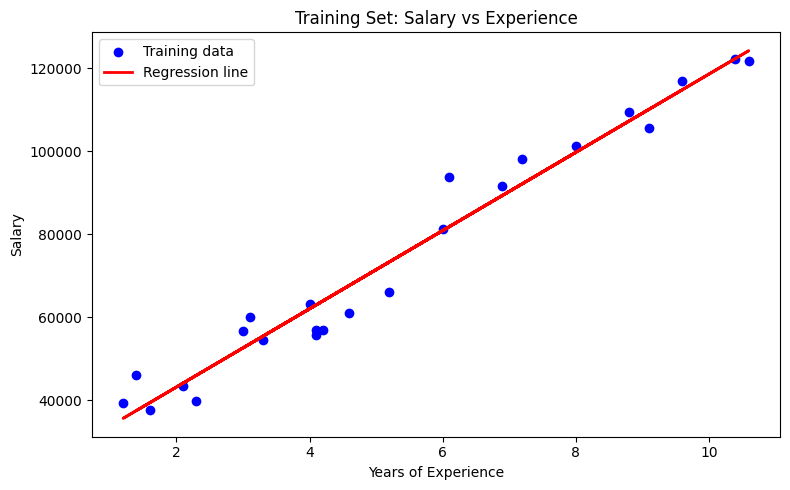

In [60]:
# ── Cell 13: Visualize – Training set ────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('Training Set: Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

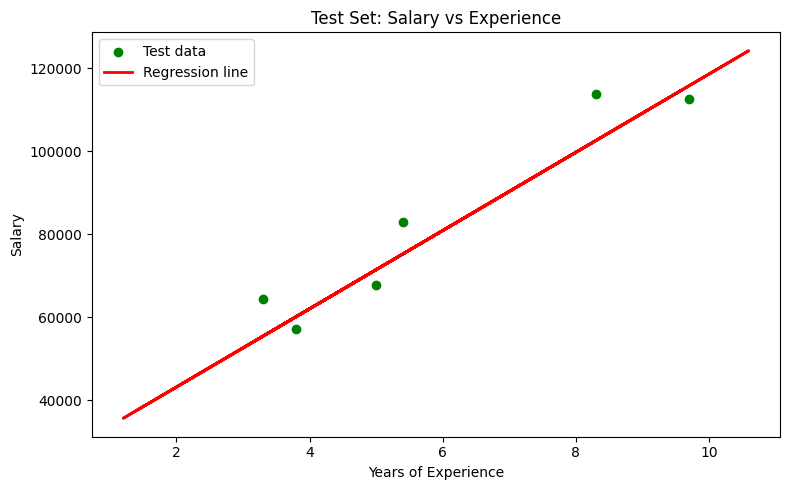

In [61]:
# ── Cell 14: Visualize – Test set ────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='green', label='Test data')
plt.plot(X_train, model.predict(X_train), color='red', linewidth=2, label='Regression line')
plt.title('Test Set: Salary vs Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.tight_layout()
plt.show()

In [62]:
# ── Cell 15: Predict (warning-free) ──────────────────────────────────────────
input_val = pd.DataFrame({'YearsExperience': [6.8]})   # named column = no warning
pred = model.predict(input_val)[0]
print(f"Predicted Salary for 6.8 years experience: ${pred:,.2f}")
# → $90,051.94

Predicted Salary for 6.8 years experience: $88,462.15
